In [2]:
import pandas as pd 

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [7]:
sns.set(style="whitegrid")
pd.set_option("display.max_columns",None)
%matplotlib inline

In [8]:
# upload files for analyst
train=pd.read_csv("train.csv")
test=pd.read_csv("test.csv")
sample=pd.read_csv("gender_submission.csv")

In [9]:
print = ("train:" , train.shape , "test:" , test.shape)

In [10]:
display(train.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [16]:
# missing value 
def missing_table(df):
    miss = df.isna().sum().sort_values(ascending=False)
    pct = (miss / len(df) * 100).round(2)
    return pd.DataFrame({
        "missing":  miss,
         "pct%":pct
    })
display(missing_table(train))
display(missing_table(test))

,missing,pct%
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Survived,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00


,missing,pct%
Cabin,327,78.23
Age,86,20.57
Fare,1,0.24
Name,0,0.00
Pclass,0,0.00
PassengerId,0,0.00
Sex,0,0.00
Parch,0,0.00
SibSp,0,0.00
Ticket,0,0.00


In [19]:
for df in (train,test):
    df["Pclass"] = df["Pclass"].astype("category")
    df["Sex"] = df["Sex"].astype("category")
    df["Embarked"] = df["Embarked"].astype("category")

In [22]:
import re

for df in (train, test):
    group_median_age = (
        df.groupby(["Sex", "Pclass"], observed=False)["Age"]
          .transform("median")
    )
    df["Age"] = df["Age"].fillna(group_median_age)

emb_mode = train["Embarked"].mode(dropna=True)[0] 
for df in (train, test):
    df["Embarked"] = df["Embarked"].fillna(emb_mode)

test["Fare"] = test["Fare"].fillna(
    test.groupby("Pclass", observed=False)["Fare"].transform("median")
)

def extract_title(name):
    m = re.search(r",\s*([^\.]+)\.", name)
    return m.group(1).strip() if m else "None"

for df in (train, test):
    df["Title"] = df["Name"].apply(extract_title)
    df["Title"] = df["Title"].replace({
        "Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs",
        "Lady": "Rare", "Countess": "Rare", "Capt": "Rare", "Col": "Rare",
        "Don": "Rare", "Dr": "Rare", "Major": "Rare", "Rev": "Rare",
        "Sir": "Rare", "Jonkheer": "Rare", "Dona": "Rare"
    }).astype("category")

display(missing_table(train))
display(missing_table(test))


,missing,pct%
Cabin,687,77.1
Survived,0,0.0
Pclass,0,0.0
Name,0,0.0
PassengerId,0,0.0
Sex,0,0.0
Age,0,0.0
Parch,0,0.0
SibSp,0,0.0
Ticket,0,0.0


,missing,pct%
Cabin,327,78.23
PassengerId,0,0.00
Name,0,0.00
Pclass,0,0.00
Sex,0,0.00
Age,0,0.00
Parch,0,0.00
SibSp,0,0.00
Ticket,0,0.00
Fare,0,0.00


In [28]:

# Overall survival rate
survival_rate = train["Survived"].mean()
print(f"Overall survival rate: {survival_rate:.3f}")

# Survival by gender
surv_by_sex = train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)
display(surv_by_sex)

# Survival by class
surv_by_pclass = train.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)
display(surv_by_pclass)

# Survival by class & gender (pivot table)
pivot_cls_sex = train.pivot_table(values="Survived", index="Pclass", columns="Sex", aggfunc="mean")
display(pivot_cls_sex)

# Survival by Embarked
display(pd.crosstab(train["Embarked"], train["Survived"], normalize="index").round(3))

# Numeric correlations (only numeric columns)
num_cols = train.select_dtypes(include=[np.number]).columns
display(train[num_cols].corr().round(2))


Overall survival rate: 0.384


C:\Users\Admin\AppData\Local\Temp\ipykernel_13824\2832676636.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_by_sex = train.groupby("Sex")["Survived"].mean().sort_values(ascending=False)


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_13824\2832676636.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  surv_by_pclass = train.groupby("Pclass")["Survived"].mean().sort_values(ascending=False)


Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_13824\2832676636.py:14: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_cls_sex = train.pivot_table(values="Survived", index="Pclass", columns="Sex", aggfunc="mean")


Sex,female,male
Pclass,,
1,0.968085,0.368852
2,0.921053,0.157407
3,0.500000,0.135447


Survived,0,1
Embarked,,
C,0.446,0.554
Q,0.610,0.390
S,0.661,0.339


,PassengerId,Survived,Age,SibSp,Parch,Fare
PassengerId,1.00,-0.01,0.04,-0.06,-0.00,0.01
Survived,-0.01,1.00,-0.06,-0.04,0.08,0.26
Age,0.04,-0.06,1.00,-0.25,-0.18,0.12
SibSp,-0.06,-0.04,-0.25,1.00,0.41,0.16
Parch,-0.00,0.08,-0.18,0.41,1.00,0.22
Fare,0.01,0.26,0.12,0.16,0.22,1.00


In [27]:
del print

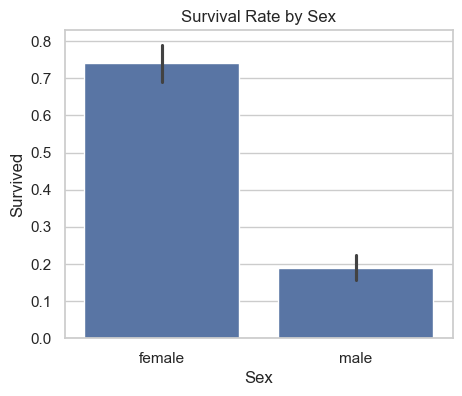

In [29]:
plt.figure(figsize=(5,4))
sns.barplot(x="Sex", y="Survived", data=train, estimator=np.mean)
plt.title("Survival Rate by Sex")
plt.show()

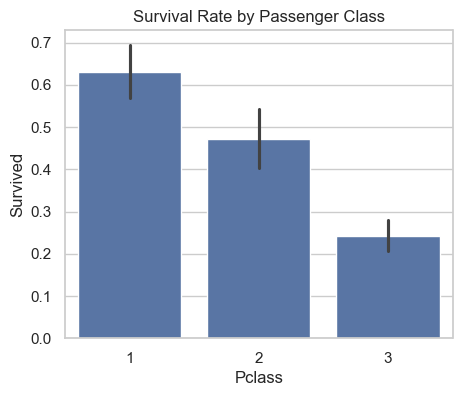

In [30]:
plt.figure(figsize=(5,4))
sns.barplot(x="Pclass", y="Survived", data=train, estimator=np.mean)
plt.title("Survival Rate by Passenger Class")
plt.show()

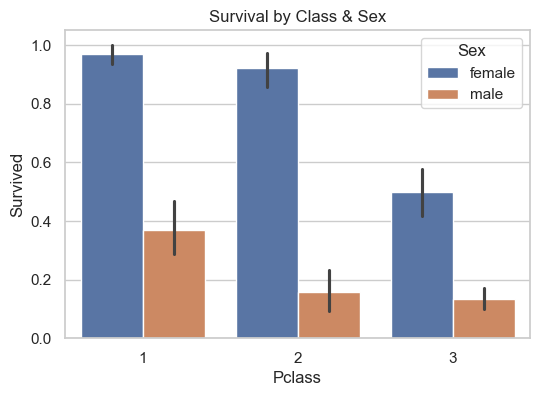

In [31]:
plt.figure(figsize=(6,4))
sns.barplot(x="Pclass", y="Survived", hue="Sex", data=train, estimator=np.mean)
plt.title("Survival by Class & Sex")
plt.show()

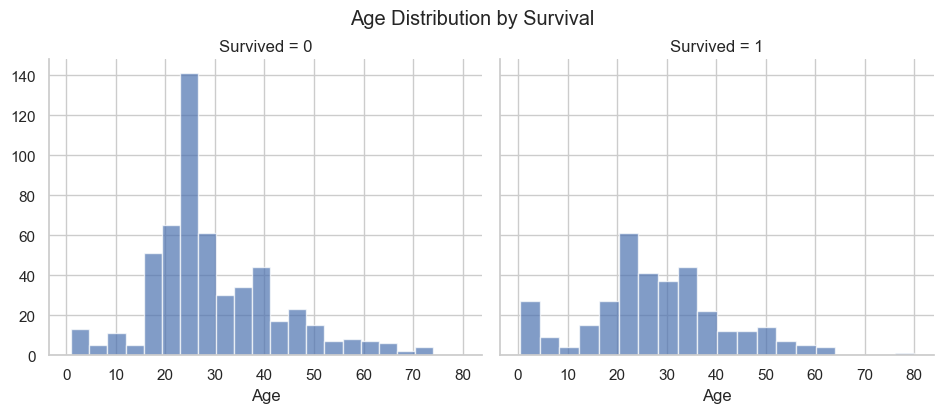

In [32]:
g = sns.FacetGrid(train, col="Survived", height=4, aspect=1.2)
g.map(plt.hist, "Age", bins=20, alpha=0.7)
g.fig.suptitle("Age Distribution by Survival", y=1.03)
plt.show()

<Figure size 600x400 with 0 Axes>

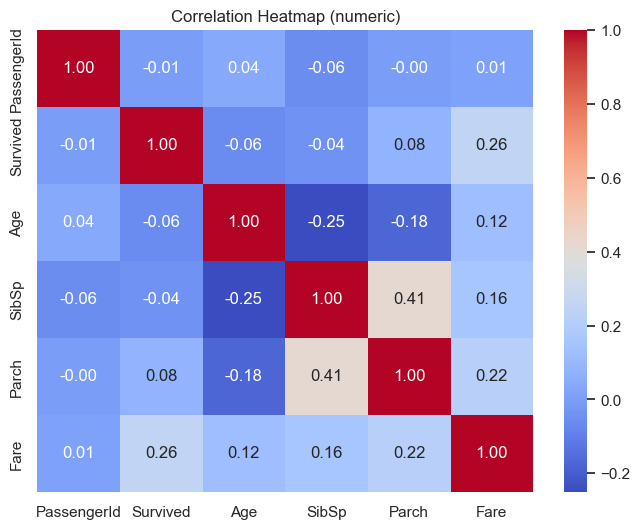

In [34]:
plt.figure(figsize=(8,6))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap (numeric)")
plt.show()